In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import glob

zips = glob.glob("/content/drive/MyDrive/**/*.zip", recursive=True)
for z in zips:
    print(z)

/content/drive/MyDrive/archive (1).zip


In [ ]:
import zipfile, os

zip_path = "/content/drive/MyDrive/archive (1).zip"

print("Extracting... (2-3 min lagenge)")
with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall("/content/HAM10000")

print("Done!")
print(os.listdir("/content/HAM10000"))

Extracting... (2-3 min lagenge)
Done!
['train', 'test', 'data']


In [ ]:
import pandas as pd
import os

# Metadata file dhundho
for root, dirs, files in os.walk("/content/HAM10000"):
    for f in files:
        if f.endswith(".csv"):
            print(os.path.join(root, f))

In [ ]:
import os

base_dir = "/content/HAM10000"
for folder in os.listdir(base_dir):
    path = os.path.join(base_dir, folder)
    if os.path.isdir(path):
        for subfolder in os.listdir(path):
            subpath = os.path.join(path, subfolder)
            if os.path.isdir(subpath):
                count = len(os.listdir(subpath))
                print(f"{folder}/{subfolder}: {count} images")

train/benign: 1440 images
train/malignant: 1197 images
test/benign: 360 images
test/malignant: 300 images
data/train: 2 images
data/test: 2 images


In [ ]:
import tensorflow as tf
import numpy as np
import os
from sklearn.model_selection import train_test_split

base_dir = "/content/HAM10000"

# Saari images aur labels collect karo
all_images = []
all_labels = []

class_names = sorted(os.listdir(os.path.join(base_dir, "train")))
print("Classes:", class_names)

for split in ["train"]:
    for label_idx, cls in enumerate(class_names):
        cls_path = os.path.join(base_dir, split, cls)
        if not os.path.isdir(cls_path):
            continue
        for img_file in os.listdir(cls_path):
            if img_file.endswith(".jpg"):
                all_images.append(os.path.join(cls_path, img_file))
                all_labels.append(label_idx)

print(f"Total images: {len(all_images)}")
print(f"Class 0 ({class_names[0]}): {all_labels.count(0)}")
print(f"Class 1 ({class_names[1]}): {all_labels.count(1)}")

# Train/Val split
from sklearn.model_selection import train_test_split
train_imgs, val_imgs, train_lbls, val_lbls = train_test_split(
    all_images, all_labels,
    test_size=0.2,
    random_state=42,
    stratify=all_labels
)
print(f"\nTrain: {len(train_imgs)} | Val: {len(val_imgs)}")

Classes: ['benign', 'malignant']
Total images: 2637
Class 0 (benign): 1440
Class 1 (malignant): 1197

Train: 2109 | Val: 528


In [ ]:
IMG_SIZE = (224, 224)

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.15),
])

def load_train(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = img / 255.0
    img = data_augmentation(img, training=True)
    return img, label

def load_val(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = img / 255.0
    return img, label

train_dataset = tf.data.Dataset.from_tensor_slices(
    (train_imgs, train_lbls)
).map(load_train, num_parallel_calls=tf.data.AUTOTUNE
).shuffle(2000).batch(32).prefetch(tf.data.AUTOTUNE)

val_dataset = tf.data.Dataset.from_tensor_slices(
    (val_imgs, val_lbls)
).map(load_val, num_parallel_calls=tf.data.AUTOTUNE
).batch(32).prefetch(tf.data.AUTOTUNE)

# MobileNetV2 model — 2 classes ke liye
base = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))
x = base(inputs, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(128, activation='relu')(x)
x = tf.keras.layers.Dropout(0.3)(x)
outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)  # Binary classification

model = tf.keras.Model(inputs, outputs)
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        "best_binary.keras",
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True,
        verbose=1
    )
]

print("Training shuru...")
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=15,
    callbacks=callbacks
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training shuru...
Epoch 1/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step - accuracy: 0.7013 - loss: 0.6101
Epoch 1: val_accuracy improved from None to 0.78030, saving model to best_binary.keras

Epoch 1: finished saving model to best_binary.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 75s 507ms/step - accuracy: 0.7558 - loss: 0.5119 - val_accuracy: 0.7803 - val_loss: 0.4588
Epoch 2/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.8184 - loss: 0.4064
Epoch 2: val_accuracy improved from 0.78030 to 0.84470, saving model to best_binary.keras

Epoch 2: finished saving model to best_binary.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 28s 65ms/step - accuracy: 0.8193 - loss: 0.4021 - val_accuracy: 0.8447 - val_loss: 0.3651
Epoch 3/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.8165 - loss: 0.3820
Epoch 3: val_accuracy did not improve from 0.84470
66/66 ━━━━━━━━━━━━━━━━━━━━ 39s 52ms/step - accuracy: 0.8274 - loss: 0.3776 - val_accuracy: 0.8277 - val_loss

In [ ]:
best = tf.keras.models.load_model("best_binary.keras")

# Validation accuracy
loss, acc = best.evaluate(val_dataset, verbose=0)
print(f"Validation Accuracy: {acc*100:.2f}%")

# Test dataset bhi evaluate karo
test_imgs, test_lbls = [], []
for cls_idx, cls in enumerate(class_names):
    cls_path = os.path.join(base_dir, "test", cls)
    for img_file in os.listdir(cls_path):
        if img_file.endswith(".jpg"):
            test_imgs.append(os.path.join(cls_path, img_file))
            test_lbls.append(cls_idx)

test_dataset = tf.data.Dataset.from_tensor_slices(
    (test_imgs, test_lbls)
).map(load_val, num_parallel_calls=tf.data.AUTOTUNE
).batch(32).prefetch(tf.data.AUTOTUNE)

test_loss, test_acc = best.evaluate(test_dataset, verbose=0)
print(f"Test Accuracy:       {test_acc*100:.2f}%")

Validation Accuracy: 84.47%
Test Accuracy:       83.79%


Classification Report:
              precision    recall  f1-score   support

      benign       0.83      0.90      0.86       288
   malignant       0.87      0.78      0.82       240

    accuracy                           0.84       528
   macro avg       0.85      0.84      0.84       528
weighted avg       0.85      0.84      0.84       528



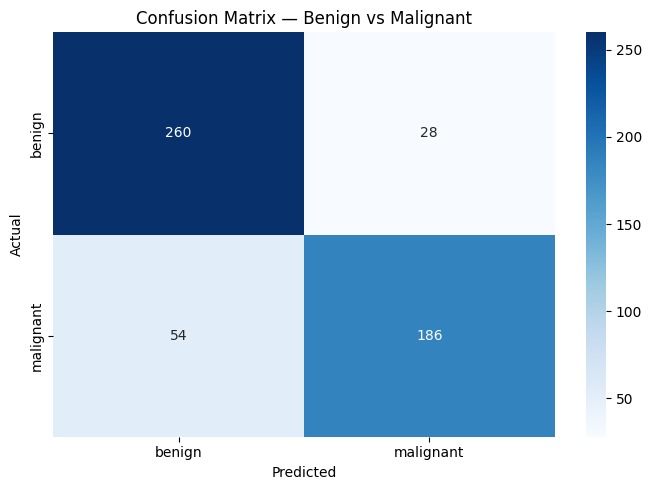

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

y_pred, y_true = [], []
for imgs, labels in val_dataset:
    preds = best.predict(imgs, verbose=0)
    y_pred.extend((preds > 0.5).astype(int).flatten())
    y_true.extend(labels.numpy())

print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

plt.figure(figsize=(7, 5))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix — Benign vs Malignant')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix_binary.png', dpi=150)
plt.show()

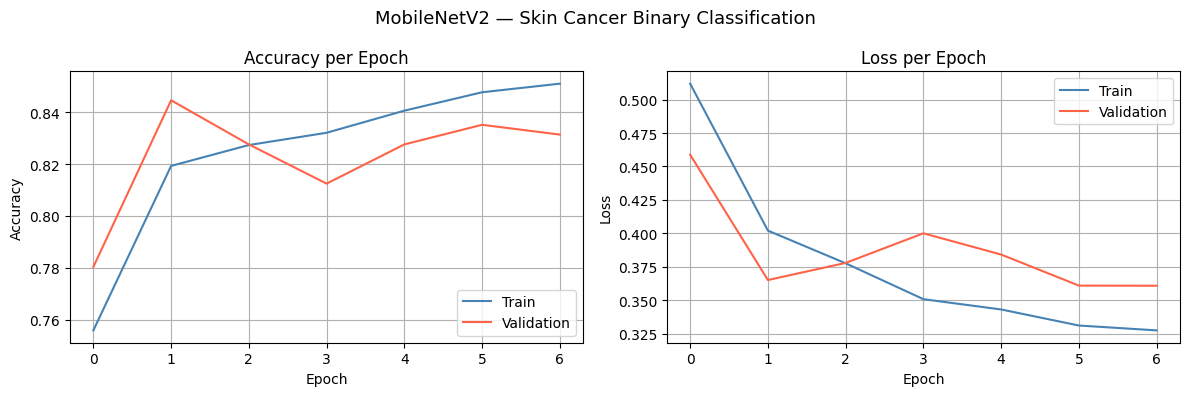

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train', color='steelblue')
plt.plot(history.history['val_accuracy'], label='Validation', color='tomato')
plt.title('Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train', color='steelblue')
plt.plot(history.history['val_loss'], label='Validation', color='tomato')
plt.title('Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.suptitle('MobileNetV2 — Skin Cancer Binary Classification', fontsize=13)
plt.tight_layout()
plt.savefig('training_history_binary.png', dpi=150)
plt.show()

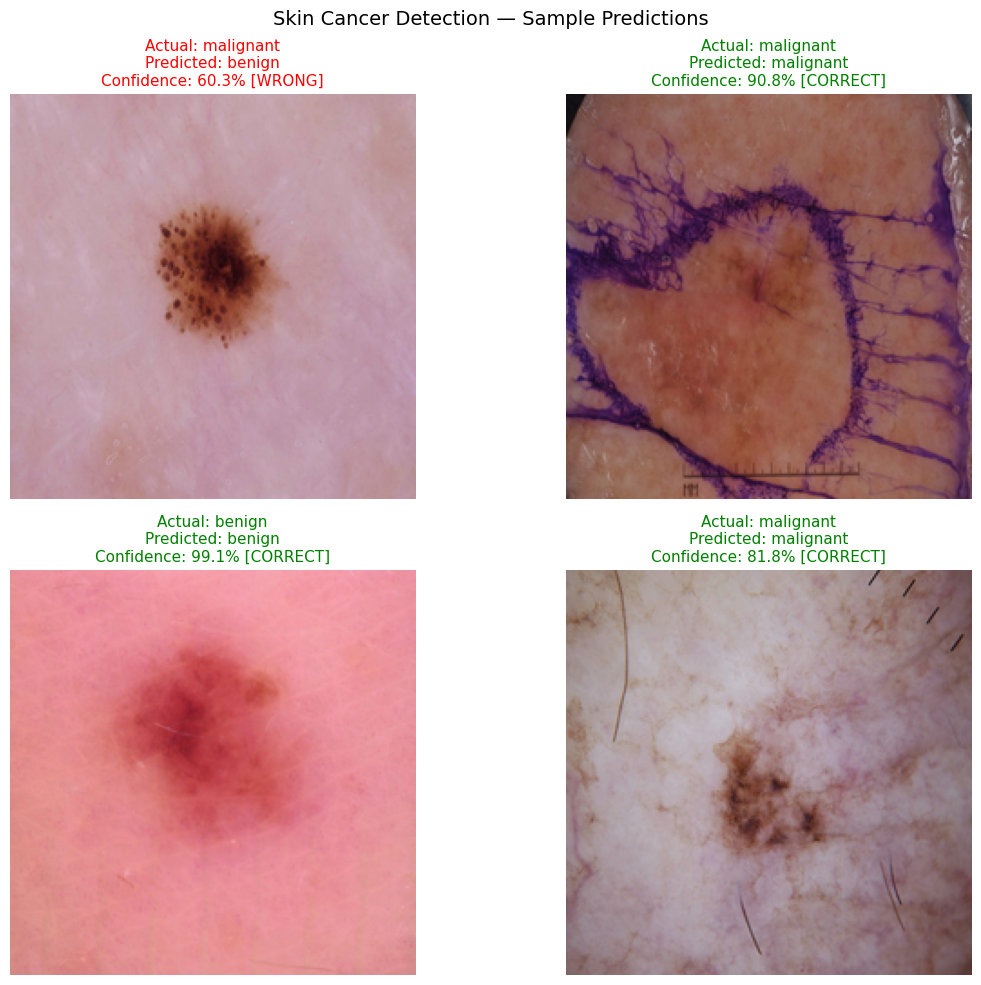

Saved!


In [ ]:
import random
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

selected = random.sample(list(zip(test_imgs, test_lbls)), 4)

for i, (img_path, true_lbl) in enumerate(selected):
    img = Image.open(img_path).convert('RGB')
    img_array = np.array(img.resize((224, 224))) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    pred = best.predict(img_array, verbose=0)[0][0]
    pred_label = "malignant" if pred > 0.5 else "benign"
    confidence = pred * 100 if pred > 0.5 else (1 - pred) * 100
    true_label = class_names[true_lbl]
    status = "CORRECT" if pred_label == true_label else "WRONG"
    color = "green" if status == "CORRECT" else "red"

    axes[i].imshow(img)
    axes[i].set_title(
        f"Actual: {true_label}\nPredicted: {pred_label}\nConfidence: {confidence:.1f}% [{status}]",
        color=color, fontsize=11
    )
    axes[i].axis('off')

plt.suptitle('Skin Cancer Detection — Sample Predictions', fontsize=14)
plt.tight_layout()
plt.savefig('sample_predictions.png', dpi=150)
plt.show()
print("Saved!")

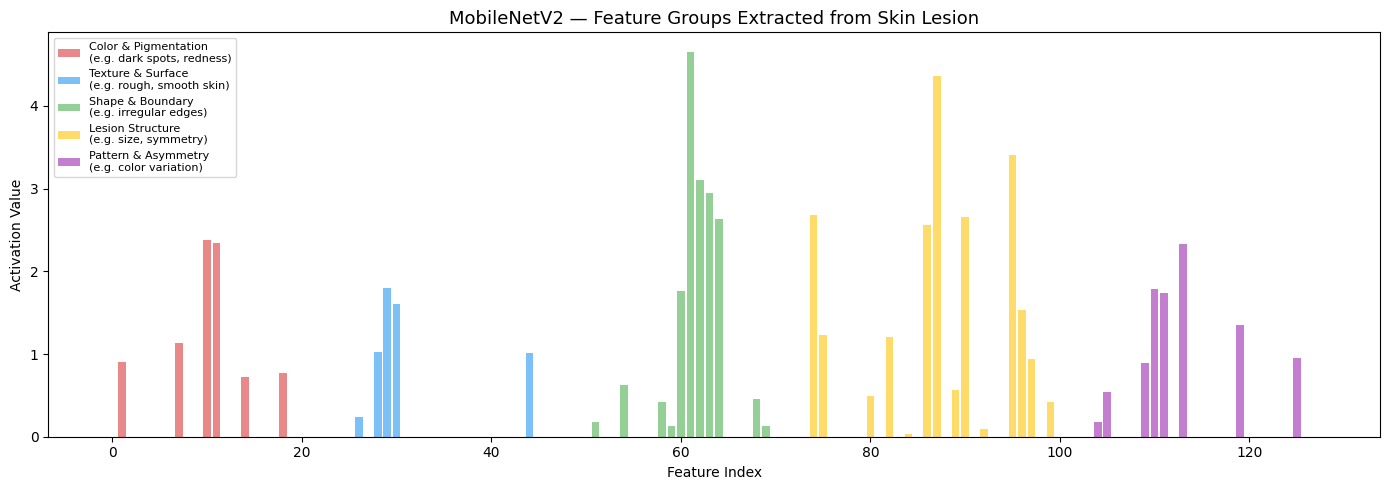

Saved!


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Feature categories jo CNN detect karta hai
feature_categories = {
    "Color & Pigmentation\n(e.g. dark spots, redness)": (0, 20, "#E57373"),
    "Texture & Surface\n(e.g. rough, smooth skin)": (20, 45, "#64B5F6"),
    "Shape & Boundary\n(e.g. irregular edges)": (45, 70, "#81C784"),
    "Lesion Structure\n(e.g. size, symmetry)": (70, 100, "#FFD54F"),
    "Pattern & Asymmetry\n(e.g. color variation)": (100, 128, "#BA68C8"),
}

features_array = features  # pehle wala features variable

plt.figure(figsize=(14, 5))
for label, (start, end, color) in feature_categories.items():
    plt.bar(range(start, end), features_array[start:end], color=color, alpha=0.85, label=label)

plt.title('MobileNetV2 — Feature Groups Extracted from Skin Lesion', fontsize=13)
plt.xlabel('Feature Index')
plt.ylabel('Activation Value')
plt.legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig('features_labeled.png', dpi=150)
plt.show()
print("Saved!")